### DECISION TREES
Decision tree is supervised machine learning algorithm, It learns from labelled data.

**What decision tree does:**
1. Model learns customer behaviour that separates the churners and non churners.
2. Creates sequences of splits: each of the splits are divided into smaller groups: Goal make the groups as pure as possible.

**Main Parts of a Decision Tree:**
1. Root Node: It contains the full training dataset before any split happens
2. Branches:
3. Leaf Nodes:
4. Internal Nodes:

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

In [2]:
df = pd.read_csv('Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [4]:
df.isna().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [5]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].isna().sum()

11

In [6]:
X = df.drop(columns=['customerID','Churn'])
y = df['Churn']

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [8]:
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X.select_dtypes(include=['object']).columns

In [9]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

In [10]:
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

In [11]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

In [12]:
# Create a pipeline that combines the preprocessor and the decision tree classifier
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', DecisionTreeClassifier(
        criterion='gini',
        max_depth=3,
        min_samples_split=20,
        min_samples_leaf=10,
        random_state=42
        ))
])

In [13]:
pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [14]:
sample_customer = X_test.iloc[[0]]
prediction = pipeline.predict(sample_customer)
print(prediction)

['No']


In [15]:
prediction_proba = pipeline.predict_proba(sample_customer)
print(prediction_proba)

[[0.92079208 0.07920792]]


In [16]:
fitted_preprocessor = pipeline.named_steps['preprocessor']
fitted_tree = pipeline.named_steps['model']

feature_names = fitted_preprocessor.get_feature_names_out()

[Text(0.5, 0.875, 'cat__Contract_Month-to-month <= 0.5\ngini = 0.39\nsamples = 5634\nvalue = [4139, 1495]\nclass = No Churn'),
 Text(0.25, 0.625, 'num__MonthlyCharges <= 0.954\ngini = 0.125\nsamples = 2532\nvalue = [2363, 169]\nclass = No Churn'),
 Text(0.375, 0.75, 'True  '),
 Text(0.125, 0.375, 'cat__OnlineSecurity_No <= 0.5\ngini = 0.076\nsamples = 1904\nvalue = [1829, 75]\nclass = No Churn'),
 Text(0.0625, 0.125, 'gini = 0.047\nsamples = 1505\nvalue = [1469, 36]\nclass = No Churn'),
 Text(0.1875, 0.125, 'gini = 0.176\nsamples = 399\nvalue = [360, 39]\nclass = No Churn'),
 Text(0.375, 0.375, 'cat__Contract_Two year <= 0.5\ngini = 0.255\nsamples = 628\nvalue = [534, 94]\nclass = No Churn'),
 Text(0.3125, 0.125, 'gini = 0.338\nsamples = 325\nvalue = [255, 70]\nclass = No Churn'),
 Text(0.4375, 0.125, 'gini = 0.146\nsamples = 303\nvalue = [279, 24]\nclass = No Churn'),
 Text(0.75, 0.625, 'cat__InternetService_Fiber optic <= 0.5\ngini = 0.489\nsamples = 3102\nvalue = [1776, 1326]\nclass

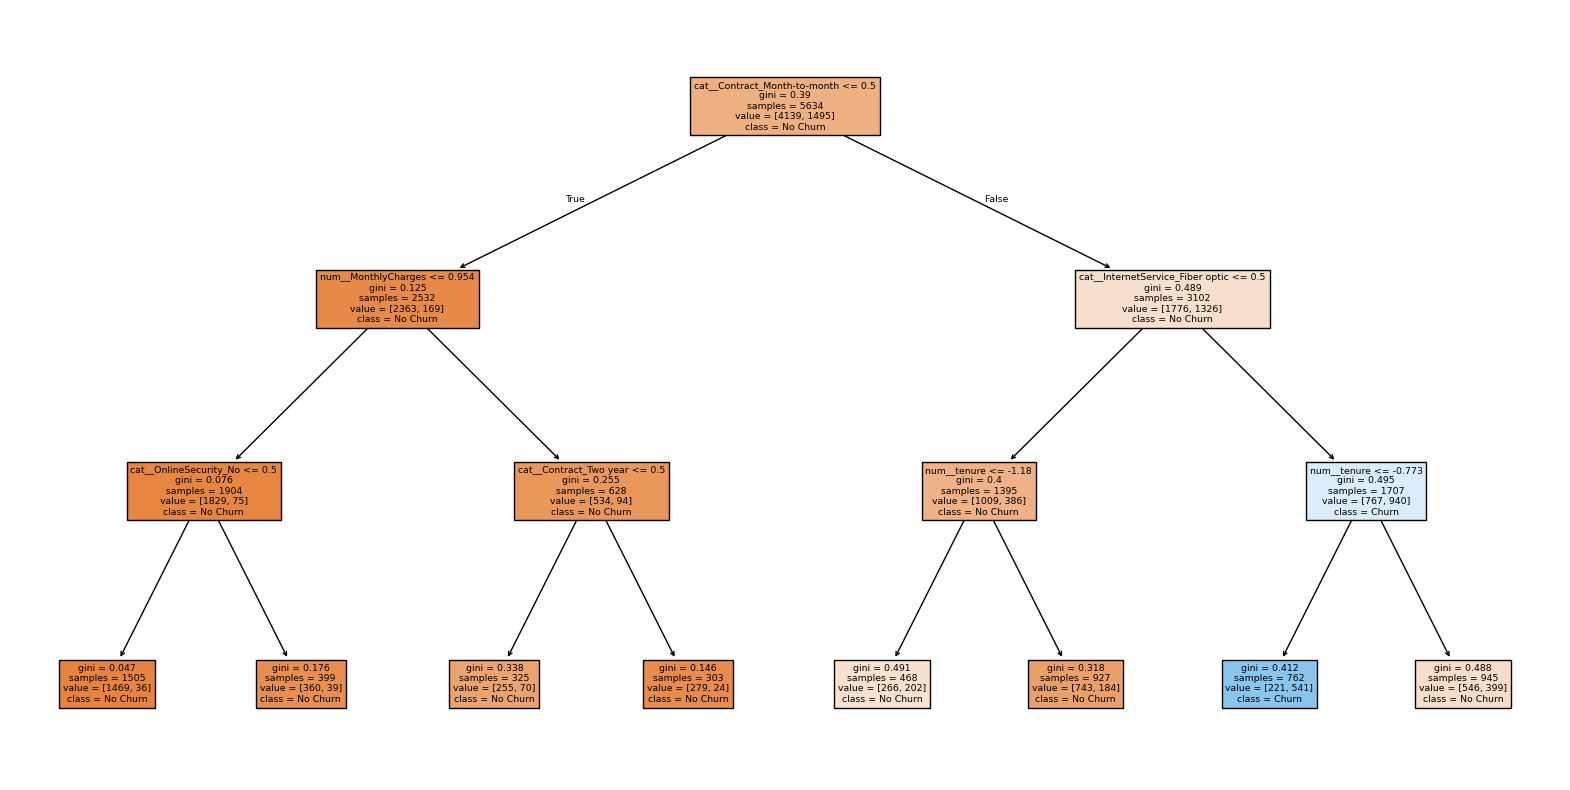

In [19]:
plt.figure(figsize=(20,10))
plot_tree(fitted_tree, 
feature_names=feature_names, 
class_names=['No Churn', 'Churn'],
filled=True
)

In [20]:
# feature importance
# information gain : the feature that was key or very important in splitting the data into different classes.

importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': fitted_tree.feature_importances_
}).sort_values(by='importance', ascending=False)

importance_df.head(5)

,feature,importance
36,cat__Contract_Month-to-month,0.602207
16,cat__InternetService_Fiber optic,0.191289
1,num__tenure,0.172074
2,num__MonthlyCharges,0.019070
38,cat__Contract_Two year,0.009654
